In [1]:
from scipy.signal import butter, sosfilt

fs=96_000

sos = butter(
    6,
    200,
    btype="highpass",
    fs=fs,
    output="sos",
)

print(sos)

[[ 0.97502896 -1.95005792  0.97502896  1.         -1.97485937  0.97502857]
 [ 1.         -2.          1.          1.         -1.98148851  0.98165828]
 [ 1.         -2.          1.          1.         -1.99307644  0.9932472 ]]


In [2]:
import numpy as np
from src.measure_ir import *
import matplotlib.pyplot as plt

In [3]:
irs = np.load(r".\data\current_irs.npz")
error_ir, ref_ir = align_irs_by_distance(irs["error_ir"], irs["ref_ir"], distance_cm=4.5, ir_len=256, fs=96_000)

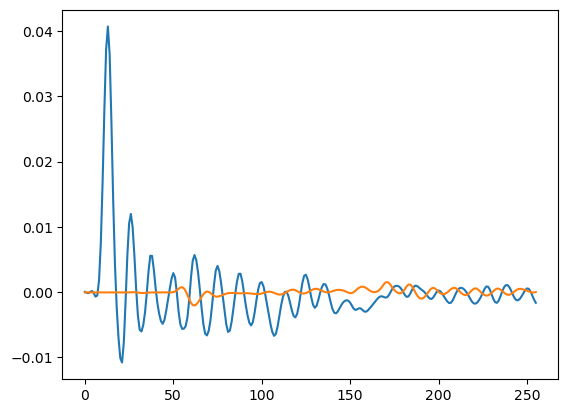

In [4]:
plt.plot(error_ir)
plt.plot(ref_ir)


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

In [6]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

source = librosa.resample(arthur, orig_sr=sr, target_sr=fs)
source_hp = sosfilt(sos, source)

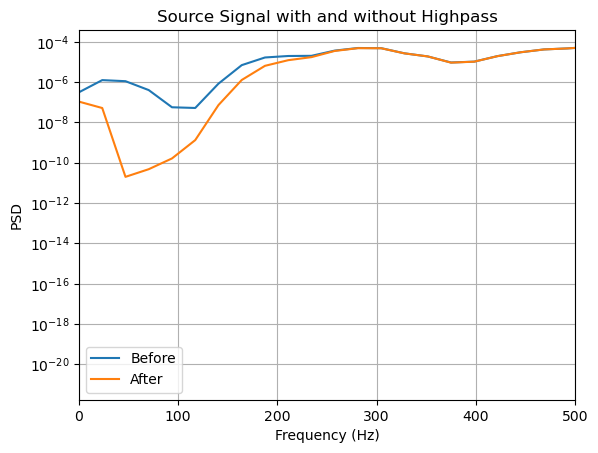

In [8]:
from scipy.signal import welch
import matplotlib.pyplot as plt

f, Pxx_before = welch(source, fs=fs, nperseg=4096)
f, Pxx_after  = welch(source_hp, fs=fs, nperseg=4096)

plt.semilogy(f, Pxx_before, label="Before")
plt.semilogy(f, Pxx_after, label="After")

plt.title('Source Signal with and without Highpass')
plt.xlim(0, 500)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.grid()
plt.show()

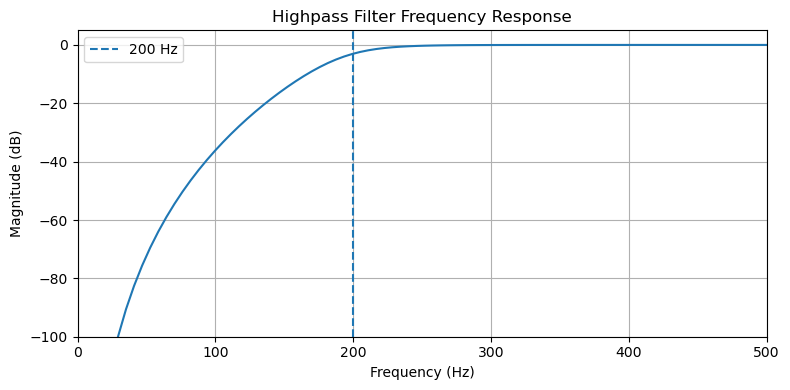

In [10]:
from scipy.signal import sosfreqz
import matplotlib.pyplot as plt
import numpy as np

# sos = your highpass SOS coefficients
# shape: (num_sections, 6)
# each row: [b0, b1, b2, a0, a1, a2]

f, H = sosfreqz(sos, worN=8192, fs=fs)

H_db = 20 * np.log10(np.maximum(np.abs(H), 1e-12))

plt.figure(figsize=(8, 4))
plt.plot(f, H_db)

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.axvline(200, linestyle="--", label="200 Hz")

plt.title("Highpass Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

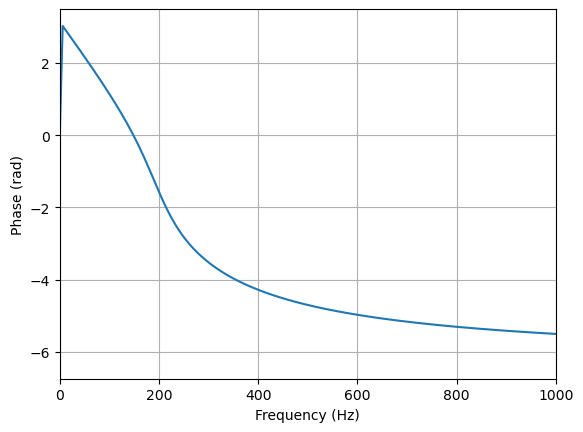

In [22]:
from scipy.signal import sosfreqz
import numpy as np
import matplotlib.pyplot as plt

f, H = sosfreqz(sos, worN=8192, fs=fs)

phase = np.unwrap(np.angle(H))

plt.plot(f, phase)
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (rad)")
plt.grid()
plt.show()

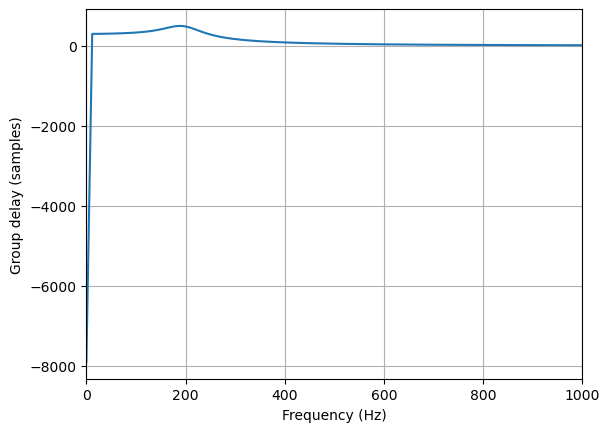

In [23]:
omega = 2 * np.pi * f

group_delay_seconds = -np.gradient(phase, omega)
group_delay_samples = group_delay_seconds * fs

plt.plot(f, group_delay_samples)
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group delay (samples)")
plt.grid()
plt.show()

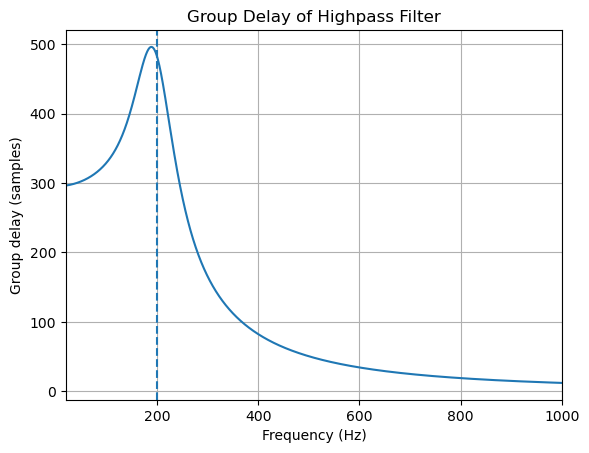

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import group_delay

f = np.linspace(20, 1000, 5000)

gd_total = np.zeros_like(f)

for section in sos:
    b = section[:3]
    a = section[3:]

    _, gd = group_delay(
        (b, a),
        w=f,
        fs=fs
    )

    gd_total += gd

plt.plot(f, gd_total)
plt.axvline(200, linestyle="--")

plt.title("Group Delay of Highpass Filter")
plt.xlim(20, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group delay (samples)")
plt.grid()
plt.show()